<a href="https://colab.research.google.com/github/MSagri05/IAT461-Final-Project/blob/main/workplace_accommodation_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Workplace Accommodation Bias and Fulfillment Analysis

**Course:** IAT 461  
**Final Project – Data Scientist Role**  
**Client:** Stin  
**Data Scientist:** Manmeet Sagri  

## Project Overview

This project analyzes a synthetic workplace accommodation dataset created for the Job Accommodation Network (JAN). The purpose of the initial exploratory data analysis is to evaluate three possible organizational strategies and determine whether accommodation outcomes are primarily influenced by cost or whether specific disability categories, departments, and HR reviewers experience disproportionate denial rates or implementation delays.

The later modeling stage will predict accommodation approval status and implementation time while accounting for relevant employee, request, workplace, and cost-related variables.

### importing the dataset from google drive

In [1]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


## 1. Environment Setup


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Data Loading

dataset is stored in google drive, so it can accessed even if runtime is disconnected

In [3]:
file_path = (
    "/content/drive/MyDrive/IAT461_Final_Project/"
    "data/workplace_accommodation_synthetic.csv"
)

try:
    df = pd.read_csv(file_path)
    print("Dataset loaded successfully.")
    print(f"Rows: {df.shape[0]}")
    print(f"Columns: {df.shape[1]}")
except FileNotFoundError:
    print("File not found. Check the folder and file names in Google Drive.")

Dataset loaded successfully.
Rows: 260
Columns: 16


In [4]:
df.head()

,request_id,disability_category,accommodation_category,employee_tenure_years,hourly_wage_usd,has_college_degree,is_cost_incurred,accommodation_cost_usd,request_severity_level,remote_work_status,department,hr_reviewer_id,approval_status,denial_reason,days_to_implement,retained_6mo
0,REQ-1000,Mental Health,Assistive technology,4.3,22.46,1,0,0.00,Medium,Hybrid,Sales,HR-107,Denied,Undue Hardship,NaN,0
1,REQ-1001,Chronic Medical,Assistive technology,5.6,21.83,1,0,0.00,Low,Remote,Operations,HR-101,Denied,Alternative Offered,NaN,0
2,REQ-1002,Cognitive/Neurological,Communication aid,7.5,26.43,1,1,2321.51,Medium,Hybrid,Engineering,HR-103,Approved,NaN,16.0,1
3,REQ-1003,Chronic Medical,Schedule modification,1.6,20.24,1,0,0.00,Low,On-site,Operations,HR-104,Denied,Undue Hardship,NaN,0
4,REQ-1004,Chronic Medical,Schedule modification,2.3,25.84,0,1,79.80,Low,Hybrid,Operations,HR-104,Approved,NaN,19.0,1


In [5]:
df.tail()

,request_id,disability_category,accommodation_category,employee_tenure_years,hourly_wage_usd,has_college_degree,is_cost_incurred,accommodation_cost_usd,request_severity_level,remote_work_status,department,hr_reviewer_id,approval_status,denial_reason,days_to_implement,retained_6mo
255,REQ-1255,Cognitive/Neurological,Assistive technology,1.4,27.95,1,0,0.0,Low,Hybrid,Engineering,HR-107,Denied,Lack of Documentation,NaN,1
256,REQ-1256,Physical/Mobility,Schedule modification,19.4,19.92,1,0,0.0,Medium,Hybrid,Finance,HR-107,Approved,NaN,7.0,1
257,REQ-1257,Chronic Medical,Assistive technology,2.4,22.72,0,0,0.0,High,On-site,Finance,HR-103,Approved,NaN,32.0,1
258,REQ-1258,Sensory,Assistive technology,3.4,16.31,1,0,0.0,Low,On-site,Customer Support,HR-106,Approved,NaN,5.0,1
259,REQ-1259,Sensory,Policy modification,2.4,25.65,1,0,0.0,Low,On-site,Customer Support,HR-108,Approved,NaN,2.0,1


In [6]:
df.sample(5, random_state=42)

,request_id,disability_category,accommodation_category,employee_tenure_years,hourly_wage_usd,has_college_degree,is_cost_incurred,accommodation_cost_usd,request_severity_level,remote_work_status,department,hr_reviewer_id,approval_status,denial_reason,days_to_implement,retained_6mo
30,REQ-1030,Cognitive/Neurological,Assistive technology,1.9,33.68,1,0,0.00,Low,Hybrid,Operations,HR-110,Partially Approved,NaN,3.0,1
181,REQ-1181,Cognitive/Neurological,Schedule modification,8.1,27.71,1,0,0.00,Medium,On-site,Customer Support,HR-102,Approved,NaN,49.0,1
223,REQ-1223,Mental Health,Policy modification,5.0,18.26,0,1,95.48,Low,Remote,Sales,HR-102,Denied,Lack of Documentation,NaN,1
185,REQ-1185,Mental Health,Physical workspace,3.3,22.43,1,1,1322.50,Medium,On-site,Engineering,HR-103,Denied,Undue Hardship,NaN,1
211,REQ-1211,Mental Health,Schedule modification,3.9,21.87,0,0,0.00,Low,On-site,Sales,HR-107,Partially Approved,NaN,31.0,1


## 3. Dataset Overview

Before doing any deeper analysis, I first wanted to understand what the dataset actually contains. Here I am checking the size of the dataset, the column names, the data types, and whether any variables are missing values. This gives me a better idea of which columns can be used directly and which ones may need special handling later.

In [7]:
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

Dataset shape: (260, 16)

Column names:
['request_id', 'disability_category', 'accommodation_category', 'employee_tenure_years', 'hourly_wage_usd', 'has_college_degree', 'is_cost_incurred', 'accommodation_cost_usd', 'request_severity_level', 'remote_work_status', 'department', 'hr_reviewer_id', 'approval_status', 'denial_reason', 'days_to_implement', 'retained_6mo']


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260 entries, 0 to 259
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   request_id              260 non-null    object 
 1   disability_category     260 non-null    object 
 2   accommodation_category  260 non-null    object 
 3   employee_tenure_years   260 non-null    float64
 4   hourly_wage_usd         260 non-null    float64
 5   has_college_degree      260 non-null    int64  
 6   is_cost_incurred        260 non-null    int64  
 7   accommodation_cost_usd  260 non-null    float64
 8   request_severity_level  260 non-null    object 
 9   remote_work_status      260 non-null    object 
 10  department              260 non-null    object 
 11  hr_reviewer_id          260 non-null    object 
 12  approval_status         260 non-null    object 
 13  denial_reason           69 non-null     object 
 14  days_to_implement       191 non-null    fl

The dataset has 260 rows and 16 columns. Most of the variables are complete, but 'denial_reason' and 'days_to_implement' have missing values.

At first this looks like a data quality issue, but these missing values may actually be connected to the approval outcome. For example, a denied request would not have an implementation time because it was never implemented. I will check this more carefully in the missing value section before deciding whether anything should be filled or removed.

In [9]:
df.describe()

,employee_tenure_years,hourly_wage_usd,has_college_degree,is_cost_incurred,accommodation_cost_usd,days_to_implement,retained_6mo
count,260.000000,260.000000,260.000000,260.000000,260.000000,191.000000,260.000000
mean,5.460769,23.103385,0.684615,0.380769,260.160769,18.382199,0.784615
std,3.988177,5.340462,0.465565,0.486512,645.648811,13.469478,0.411882
min,0.400000,9.450000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,2.400000,19.562500,0.000000,0.000000,0.000000,9.000000,1.000000
50%,4.500000,22.630000,1.000000,0.000000,0.000000,15.000000,1.000000
75%,7.600000,26.662500,1.000000,1.000000,210.995000,25.000000,1.000000
max,20.800000,38.340000,1.000000,1.000000,7588.770000,72.000000,1.000000


The numeric summary gives me a first look at the ranges in the data. Employee tenure ranges from less than one year to over 20 years, and accommodation costs range from $ 0 to more than $ 7,000.

The accommodation cost column also looks very uneven because many requests have a cost of $0, while a small number are much more expensive. This means the average cost may not describe the dataset very well, so later I will look at the distribution and compare cost against approval status instead of relying only on the mean.

In [10]:
column_summary = pd.DataFrame({
    "data_type": df.dtypes,
    "non_null_count": df.notnull().sum(),
    "missing_count": df.isnull().sum(),
    "missing_percentage": (df.isnull().sum() / len(df) * 100).round(2),
    "unique_values": df.nunique()
})

column_summary

,data_type,non_null_count,missing_count,missing_percentage,unique_values
request_id,object,260,0,0.00,260
disability_category,object,260,0,0.00,5
accommodation_category,object,260,0,0.00,5
employee_tenure_years,float64,260,0,0.00,113
hourly_wage_usd,float64,260,0,0.00,244
has_college_degree,int64,260,0,0.00,2
is_cost_incurred,int64,260,0,0.00,2
accommodation_cost_usd,float64,260,0,0.00,100
request_severity_level,object,260,0,0.00,3
remote_work_status,object,260,0,0.00,3


This summary confirms that most columns are complete and have a reasonable number of categories. The main exceptions are 'denial_reason' and 'days_to_implement'

I can also see that 'request_id' is unique for every row, which is what I expected. Variables such as disability category, accommodation category, department, approval status, and HR reviewer contain a small number of categories, so they should be useful for group comparisons and visualizations.

### Duplicate Records

Before calculating approval rates or averages, I wanted to make sure the same request was not included more than once. Duplicate rows could make some categories look more common than they actually are.

In [11]:
print("Fully duplicated rows:", df.duplicated().sum())
print("Duplicated request IDs:", df["request_id"].duplicated().sum())

Fully duplicated rows: 0
Duplicated request IDs: 0


There are no fully duplicated rows and no repeated request IDs. This means each row appears to represent one unique accommodation request, so I do not need to remove duplicates at this stage.

### Categorical Value Review

Next, I am checking the unique values and counts in the categorical columns. This helps me catch inconsistent spelling, unexpected labels, or categories with very few records before I start comparing approval rates.

In [12]:
categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    print(f"\n{column}")
    print(df[column].value_counts(dropna=False))


request_id
request_id
REQ-1259    1
REQ-1000    1
REQ-1001    1
REQ-1002    1
REQ-1243    1
           ..
REQ-1008    1
REQ-1007    1
REQ-1006    1
REQ-1005    1
REQ-1004    1
Name: count, Length: 260, dtype: int64

disability_category
disability_category
Mental Health             64
Physical/Mobility         59
Cognitive/Neurological    53
Sensory                   44
Chronic Medical           40
Name: count, dtype: int64

accommodation_category
accommodation_category
Schedule modification    75
Assistive technology     70
Physical workspace       58
Policy modification      30
Communication aid        27
Name: count, dtype: int64

request_severity_level
request_severity_level
Low       112
Medium    110
High       38
Name: count, dtype: int64

remote_work_status
remote_work_status
On-site    122
Hybrid     103
Remote      35
Name: count, dtype: int64

department
department
Customer Support    72
Operations          61
Sales               53
Engineering         42
Finance            

The category labels appear consistent, so I do not see any obvious spelling or formatting problems that need to be cleaned.

Some groups are more common than others. For example, Customer Support has more records than Finance, and low and medium severity requests are much more common than high severity requests. I will keep these differences in mind later because percentages will be more useful than raw counts when comparing groups.

## 4. Missing Value Analysis

The next thing I wanted to understand was why some values are missing. I do not want to automatically fill or delete them because the missing values may have a logical meaning.

Based on the dataset description, denied requests should not have an implementation time, while approved requests should not have a denial reason. I am checking whether the dataset actually follows this pattern.

In [13]:
missing_values = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percentage": (df.isnull().sum() / len(df) * 100).round(2)
})

missing_values[missing_values["missing_count"] > 0].sort_values(
    by="missing_percentage",
    ascending=False
)

,missing_count,missing_percentage
denial_reason,191,73.46
days_to_implement,69,26.54


Only two columns contain missing values. 'denial_reason' is missing in 191 rows, while 'days_to_implement' is missing in 69 rows.

Instead of treating these as random missing values, I need to compare them with 'approval_status' to see whether the missingness is expected.

In [14]:
missing_days_by_status = pd.crosstab(
    df["approval_status"],
    df["days_to_implement"].isna(),
    margins=True
)

missing_days_by_status.columns = ["days_available", "days_missing", "total"]
missing_days_by_status

,days_available,days_missing,total
approval_status,,,
Approved,141,0,141
Denied,0,69,69
Partially Approved,50,0,50
All,191,69,260


This result confirms that all 69 denied requests are missing days_to_implement, while approved and partially approved requests have implementation times.

This makes sense because a denied accommodation was never implemented. Because of this, I should not fill these missing values with an average or median. For delay analysis, I will only use approved and partially approved requests.

In [15]:
missing_reason_by_status = pd.crosstab(
    df["approval_status"],
    df["denial_reason"].isna(),
    margins=True
)

missing_reason_by_status.columns = ["reason_available", "reason_missing", "total"]
missing_reason_by_status

,reason_available,reason_missing,total
approval_status,,,
Approved,0,141,141
Denied,69,0,69
Partially Approved,0,50,50
All,69,191,260


The second check also follows the expected pattern. All denied requests have a denial reason, while approved and partially approved requests do not.

This means the missing values in 'denial_reason' are also meaningful rather than accidental. I will keep them as missing because adding a fake category or filling them with the mode would incorrectly suggest that approved requests had a denial reason.

### What I learned from the missing values

The missing values are connected to how the accommodation process works, so they are not regular data errors.

A denied request has no implementation time because it was never completed. An approved or partially approved request has no denial reason because it was not denied.

For this reason, I am not going to fill these values using the mean, median, or mode. Later, I will create separate subsets depending on the question being analyzed. For example, implementation delay will only be studied using requests that were approved or partially approved.

After talking to Stin, I also know that the main focus should be on whether disability category, HR reviewer, department, cost, and other control variables are connected to approval and delay outcomes. The missing-value handling needs to support those comparisons rather than changing the meaning of the data.

# 5. Initial Exploratory Data Analysis

Now that I understand the structure and quality of the dataset, I want to start exploring the actual patterns inside it.

At this stage, I am not trying to prove anything yet. Instead, I want to see whether any trends immediately stand out that could help answer the client's questions. In particular, I want to investigate whether approval decisions appear to vary by disability category, department, accommodation cost, or HR reviewer.

## 5.1 Approval Status Distribution

The first thing I want to check is the overall approval outcome.

If almost every request is approved (or denied), it would be difficult to compare groups later. Understanding the overall distribution also gives me a baseline before looking at specific disability categories or departments.

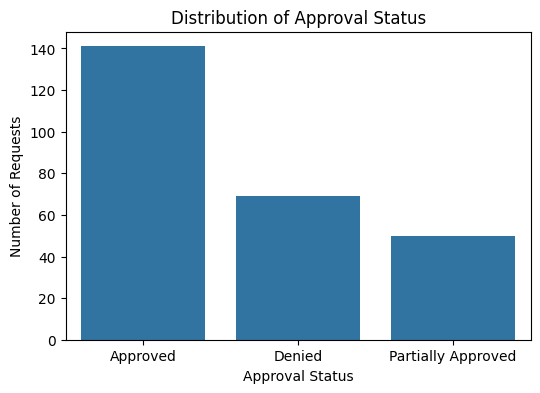

approval_status
Approved              141
Denied                 69
Partially Approved     50
Name: count, dtype: int64


In [16]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="approval_status",
    order=df["approval_status"].value_counts().index
)

plt.title("Distribution of Approval Status")
plt.xlabel("Approval Status")
plt.ylabel("Number of Requests")

plt.show()

print(df["approval_status"].value_counts())

from this graph, i can see that approved requests make up the largest group in the dataset, followed by denied requests and then partially approved requests.

this tells me that the dataset is not perfectly balanced, but it is also not extremely one-sided. since there are a reasonable number of denied and partially approved requests, i should still be able to compare different groups later and look for patterns that may explain why some requests are approved while others are not.

## 5.2 Disability Category Distribution

Next, I want to see how the accommodation requests are distributed across disability categories.

If one category has significantly more requests than another, I should compare percentages rather than raw counts later when evaluating approval rates.

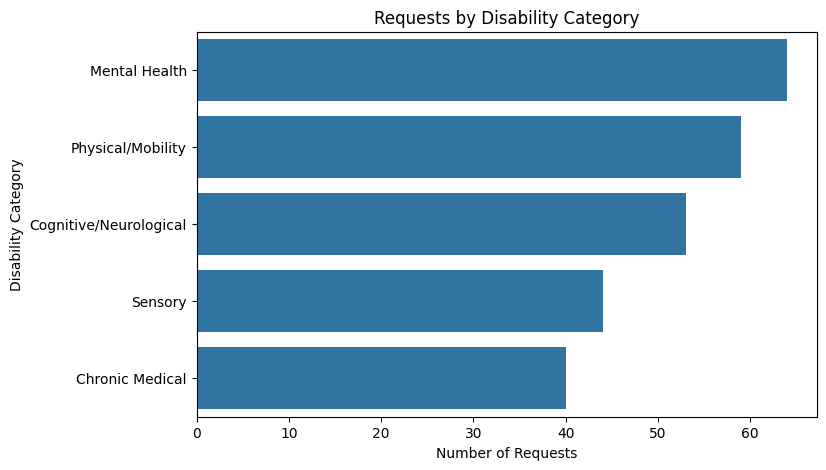

disability_category
Mental Health             64
Physical/Mobility         59
Cognitive/Neurological    53
Sensory                   44
Chronic Medical           40
Name: count, dtype: int64


In [17]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    y="disability_category",
    order=df["disability_category"].value_counts().index
)

plt.title("Requests by Disability Category")
plt.xlabel("Number of Requests")
plt.ylabel("Disability Category")

plt.show()

print(df["disability_category"].value_counts())

the requests are spread across all five disability categories, although some categories appear slightly more often than others. mental health has the highest number of requests, while chronic medical has the fewest.

the differences are not very large, so each category has enough observations to compare approval outcomes later. however, because the categories are not exactly the same size, i should compare approval percentages instead of only looking at raw counts when deciding whether certain groups experience different outcomes.

## 5.3 approval status by disability category

after looking at how many requests belong to each disability category, i now want to see whether the approval outcome changes across those categories.

this is one of the main questions in the project. if some disability categories have noticeably higher denial rates than others, it could suggest that a general training program for everyone may not be the most effective solution. instead, it may point toward specific areas that deserve closer investigation.

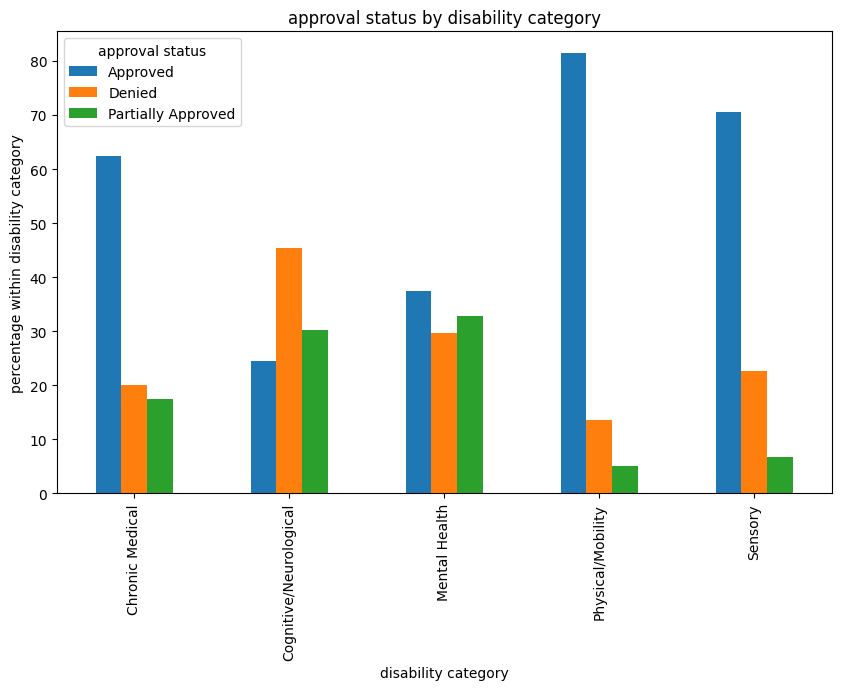

approval_status,Approved,Denied,Partially Approved
disability_category,,,
Chronic Medical,62.5,20.0,17.5
Cognitive/Neurological,24.5,45.3,30.2
Mental Health,37.5,29.7,32.8
Physical/Mobility,81.4,13.6,5.1
Sensory,70.5,22.7,6.8


In [18]:
approval_by_disability = pd.crosstab(
    df["disability_category"],
    df["approval_status"],
    normalize="index"
) * 100

approval_by_disability = approval_by_disability.round(1)

approval_by_disability.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("approval status by disability category")
plt.xlabel("disability category")
plt.ylabel("percentage within disability category")
plt.legend(title="approval status")

plt.show()

approval_by_disability

from this graph, i can already see that approval outcomes are not evenly distributed across disability categories.

physical/mobility and sensory requests appear to have much higher approval rates, while cognitive/neurological requests have the highest denial rate and one of the lowest approval rates. mental health requests also appear to have a more balanced mix of approvals, denials, and partial approvals.

this does not prove that bias exists, but it does suggest that disability category may be related to the final decision. because of this, i think it is worth exploring these categories in more detail later instead of assuming that every disability group experiences the same approval process.

## 5.4 approval status by hr reviewer

after comparing disability categories, i now want to see whether approval outcomes also vary across different hr reviewers.

according to the project description, one possible recommendation is to audit specific hr reviewers instead of applying organization-wide changes. if some reviewers consistently approve or deny more requests than others, this could suggest that reviewer-specific patterns are worth investigating further.

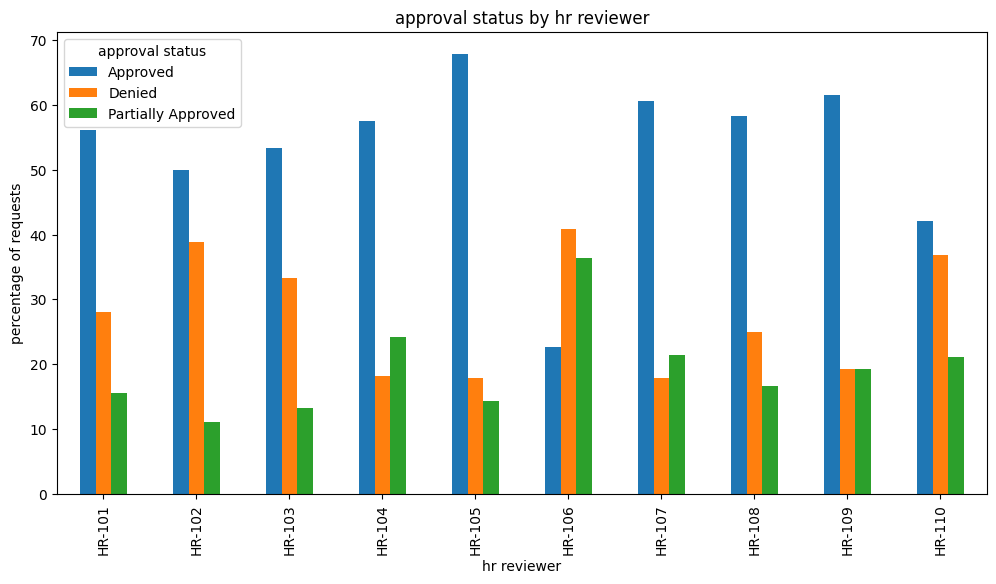

approval_status,Approved,Denied,Partially Approved
hr_reviewer_id,,,
HR-101,56.2,28.1,15.6
HR-102,50.0,38.9,11.1
HR-103,53.3,33.3,13.3
HR-104,57.6,18.2,24.2
HR-105,67.9,17.9,14.3
HR-106,22.7,40.9,36.4
HR-107,60.7,17.9,21.4
HR-108,58.3,25.0,16.7
HR-109,61.5,19.2,19.2


In [19]:
approval_by_reviewer = pd.crosstab(
    df["hr_reviewer_id"],
    df["approval_status"],
    normalize="index"
) * 100

approval_by_reviewer = approval_by_reviewer.round(1)

approval_by_reviewer.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("approval status by hr reviewer")
plt.xlabel("hr reviewer")
plt.ylabel("percentage of requests")
plt.legend(title="approval status")

plt.show()

approval_by_reviewer

from this graph, i can see that approval outcomes are not completely consistent across hr reviewers.

for example, hr-105 has the highest approval rate, while hr-106 has the lowest approval rate and the highest denial rate. reviewers such as hr-102 and hr-110 also appear to deny a larger percentage of requests than some of the others.

this does not automatically mean that individual reviewers are biased because other factors, such as disability category, request severity, or department, could also influence these outcomes. however, the differences are noticeable enough that hr reviewer should be considered as an important variable in the later analysis and predictive models.

## 5.5 accommodation cost distribution

one of the client's assumptions is that expensive accommodations may be the main reason requests are denied. before comparing costs with approval outcomes, i first want to understand how accommodation costs are distributed across the dataset.

this will help me see whether most requests are relatively inexpensive or whether high-cost requests are common.

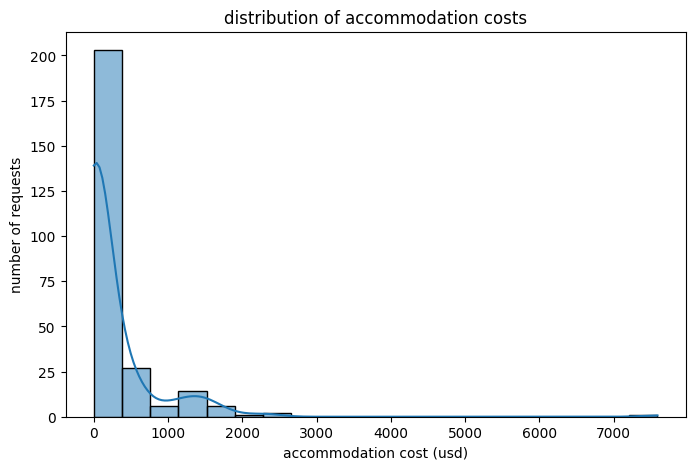

,accommodation_cost_usd
count,260.000000
mean,260.160769
std,645.648811
min,0.000000
25%,0.000000
50%,0.000000
75%,210.995000
max,7588.770000


In [20]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["accommodation_cost_usd"],
    bins=20,
    kde=True
)

plt.title("distribution of accommodation costs")
plt.xlabel("accommodation cost (usd)")
plt.ylabel("number of requests")

plt.show()

df["accommodation_cost_usd"].describe()

this distribution is heavily right-skewed. most accommodation requests have little to no cost, while only a small number of requests are associated with very high costs.

i also noticed that the median accommodation cost is dollar 0 , which means at least half of all requests did not require any direct financial cost. however, there are a few expensive requests that increase the average cost to around $260.

this is interesting because one of the client's assumptions is that expensive accommodations are the main reason requests are denied. based on this distribution alone, high-cost accommodations appear to be relatively uncommon. in the next step, i want to compare accommodation cost with approval status to see whether expensive requests are actually more likely to be denied.

## 5.6 accommodation cost by approval status

after looking at the overall distribution of accommodation costs, i now want to compare costs across different approval outcomes.

if denied requests consistently have much higher accommodation costs than approved requests, this would support the client's assumption that cost is one of the main reasons requests are rejected. however, if the cost distributions are similar, it would suggest that other factors may play a larger role in the decision-making process.

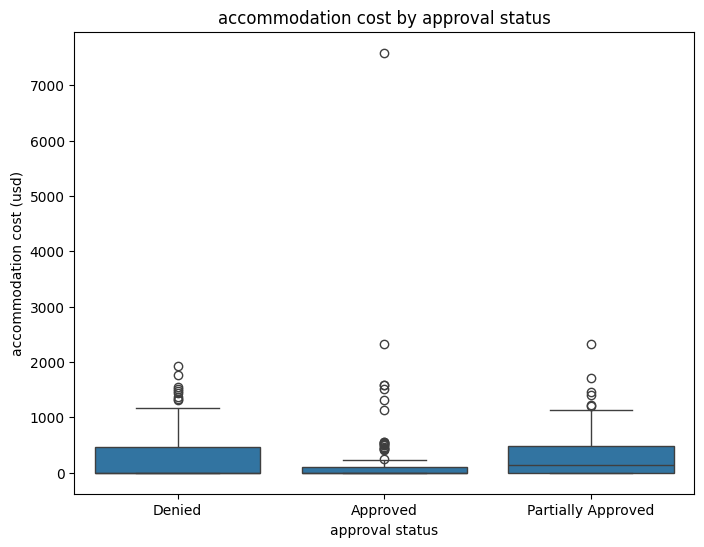

,count,mean,std,min,25%,50%,75%,max
approval_status,,,,,,,,
Approved,141.0,185.63,716.64,0.0,0.0,0.00,95.23,7588.77
Denied,69.0,345.01,544.11,0.0,0.0,0.00,469.73,1930.61
Partially Approved,50.0,353.24,538.76,0.0,0.0,133.36,479.16,2326.78


In [21]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x="approval_status",
    y="accommodation_cost_usd"
)

plt.title("accommodation cost by approval status")
plt.xlabel("approval status")
plt.ylabel("accommodation cost (usd)")

plt.show()

df.groupby("approval_status")["accommodation_cost_usd"].describe().round(2)

from this boxplot, i do not see a clear difference in accommodation costs across the three approval outcomes. while there are a few very expensive requests in every group, most requests have relatively low costs regardless of whether they were approved, denied, or partially approved.

this suggests that accommodation cost alone may not be the main factor influencing approval decisions. instead, other variables such as disability category, hr reviewer, department, or request severity may have a stronger relationship with the final outcome. i will explore these variables further during the modeling stage.

## 5.7 correlation between numerical variables

finally, i want to see whether any of the numerical variables have obvious linear relationships with one another.

a correlation heatmap gives a quick overview of how strongly variables move together. while correlation does not imply causation, it can help identify relationships that may be useful to explore later when building predictive models.

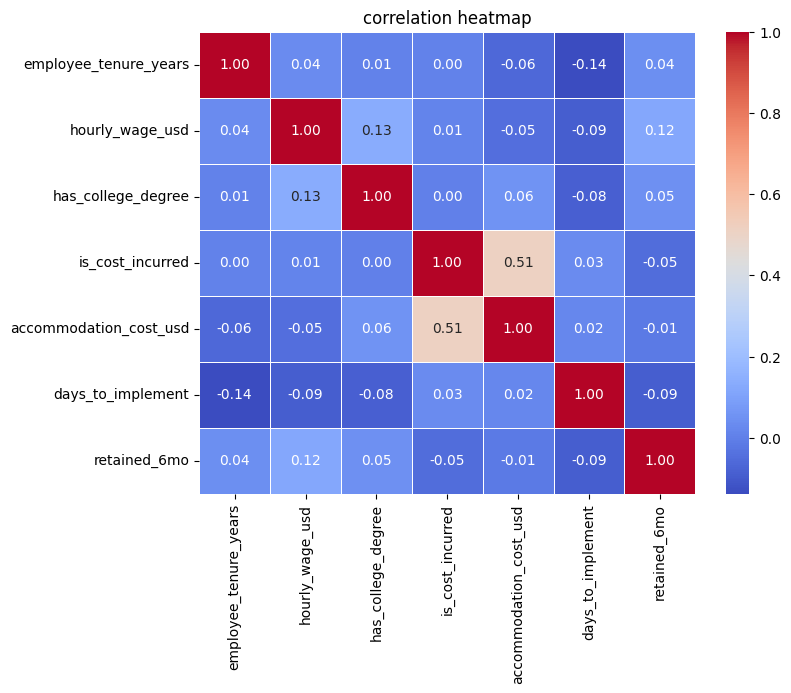

,employee_tenure_years,hourly_wage_usd,has_college_degree,is_cost_incurred,accommodation_cost_usd,days_to_implement,retained_6mo
employee_tenure_years,1.000000,0.035124,0.007867,0.004545,-0.062473,-0.137830,0.040435
hourly_wage_usd,0.035124,1.000000,0.134849,0.009384,-0.048910,-0.089093,0.119061
has_college_degree,0.007867,0.134849,1.000000,0.003803,0.055788,-0.084999,0.047084
is_cost_incurred,0.004545,0.009384,0.003803,1.000000,0.514846,0.033773,-0.051579
accommodation_cost_usd,-0.062473,-0.048910,0.055788,0.514846,1.000000,0.018571,-0.013864
days_to_implement,-0.137830,-0.089093,-0.084999,0.033773,0.018571,1.000000,-0.090332
retained_6mo,0.040435,0.119061,0.047084,-0.051579,-0.013864,-0.090332,1.000000


In [22]:
# select only numerical columns
numeric_df = df.select_dtypes(include=["number"])

# calculate correlations
correlation_matrix = numeric_df.corr(numeric_only=True)

# plot heatmap
plt.figure(figsize=(8,6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("correlation heatmap")

plt.show()

correlation_matrix

the heatmap shows that most of the numerical variables have weak correlations with one another.

the strongest relationship is between 'is_cost_incurred' and 'accommodation_cost_usd', with a correlation of about 0.51. this makes sense because requests marked as having a direct cost are more likely to have a higher accommodation cost.

other relationships are much weaker. for example, accommodation cost has almost no linear relationship with 'days_to_implement' or 'retained_6mo'. implementation time also has only a weak negative relationship with retention.

this suggests that the main patterns in the dataset may not be explained by simple numerical correlations alone. categorical variables such as disability category, hr reviewer, department, request severity, and approval status will likely be more important in the later modeling stage.

# 6. initial findings

after completing the initial exploratory data analysis, i identified several patterns that will guide the next stage of the project.

- approval outcomes vary across disability categories, with some categories experiencing noticeably higher denial rates than others.
- approval outcomes also differ between hr reviewers, suggesting that reviewer-specific patterns may be worth investigating further.
- accommodation costs are heavily right-skewed, with most requests having little or no direct financial cost.
- based on the boxplot comparison, accommodation cost alone does not appear to explain why requests are approved or denied.
- these findings suggest that multiple variables, rather than a single factor, may influence accommodation decisions. in the next stage of the project, i will build predictive models to better understand which variables have the strongest relationship with approval status and implementation delays.

**what this means for options a, b, and c**

after talking to stin, i know he wants disability_category and hr_reviewer_id to be the main things im focused on, but everything else (wage, tenure, degree, remote status, department, severity, cost) needs to be treated as control variables. the idea is to check if disability category and hr reviewer still matter once i account for those other things, so nobody can argue "its not bias, its just that mental health cases happen to be in departments with tighter budgets" or something like that.

stin also said i dont need a full stat test to disprove option a and b, clear visuals plus reasoning is enough for now. a correlation matrix is optional if i want extra proof later, but he said not to spend too much time on that part.

based on what ive seen so far:

option a (train everyone the same amount) doesnt really hold up. approval rates are not close across disability categories, physical/mobility gets approved 81.4% of the time but cognitive/neurological only gets approved 24.5% of the time. if the problem was just general awareness, id expect these numbers to look more similar across categories, not this spread out.

option b (its mainly about cost) also doesnt fully hold up. most requests cost $0 to begin with, and looking at the boxplot, denied requests dont clearly cost more than approved ones, the ranges actually overlap a lot. so cost by itself isnt explaining why some categories or reviewers deny more often.

option c (look closer at specific categories and reviewers) is what the data actually points to right now. both disability category and hr reviewer show real differences in approval rate that cost alone doesnt explain.

next step for me is to bring in the control variables stin mentioned and start setting up for phase 2 modeling. i still need to check days_to_implement by disability category too, since delay is the other outcome the client cares about, not just approval status.

### **checkpoint 2 client check-in**

reached out to stin to get feedback on the notebook so far before finishing up. he said it looks super thorough and didnt have much feedback, the eda was specific enough that he could follow the reasoning without me needing to explain more.

the one thing he pointed out was the note i left at the end about days_to_implement by disability category, i had flagged it as a next step but hadnt actually built it out yet. so thats confirming im on the right track with everything else, i just need to go back and finish that piece.

going forward: adding the days_to_implement by disability category analysis next, since thats the other outcome (delay, not just approval) that the client originally cared about.

# 6. eda findings and strategy direction

before moving into modeling, i want to summarize what the initial exploration suggests about the client's three proposed strategies.

the eda shows that approval outcomes are not evenly distributed across disability categories or hr reviewers. some disability categories have noticeably different approval and denial rates, and some reviewers also show different decision patterns.

at the same time, accommodation cost does not appear to explain approval outcomes by itself. most accommodation requests have little or no direct cost, and denied requests are not consistently more expensive than approved requests.

based on these initial findings, option c appears to be the most useful direction to investigate further. instead of assuming that the issue affects every department or disability category equally, or assuming that financial cost is the main barrier, the data suggests that specific factors may be connected to approval decisions and implementation delays.

however, these eda results only show associations. they do not prove that disability category or individual hr reviewers directly cause an approval or denial. the next step is to use supervised predictive models while controlling for other available variables.

# 7. problem 1: predicting approval status

the first modeling problem is to predict the outcome of an accommodation request.

the target variable is approval_status, which already contains known outcomes:

- approved
- denied
- partially approved

because the outcome is already labelled, this is a supervised classification problem.

i want to include disability category and hr reviewer because they are central to the client's question, while also including other workplace and request-related variables as controls. this will help me see whether patterns involving disability category or reviewer still matter when factors such as department, request severity, accommodation cost, tenure, wage, and remote work status are also considered.

## 7.1 selecting features

before training the model, i need to separate variables that would realistically be known when an accommodation request is being reviewed from variables that only become known afterward.

i will remove request_id because it is only an identifier. i will also exclude denial_reason, days_to_implement, and retained_6mo because these variables occur after the approval decision and could create data leakage.

In [23]:
approval_features = [
    "disability_category",
    "accommodation_category",
    "employee_tenure_years",
    "hourly_wage_usd",
    "has_college_degree",
    "is_cost_incurred",
    "accommodation_cost_usd",
    "request_severity_level",
    "remote_work_status",
    "department",
    "hr_reviewer_id"
]

X = df[approval_features]
y = df["approval_status"]

print("feature matrix shape:", X.shape)
print("target shape:", y.shape)

print("\ntarget distribution:")
print(y.value_counts())

print("\ntarget percentages:")
print((y.value_counts(normalize=True) * 100).round(1))

feature matrix shape: (260, 11)
target shape: (260,)

target distribution:
approval_status
Approved              141
Denied                 69
Partially Approved     50
Name: count, dtype: int64

target percentages:
approval_status
Approved              54.2
Denied                26.5
Partially Approved    19.2
Name: proportion, dtype: float64


the dataset contains 260 requests and 11 features that will be used to predict approval status. approved requests are the largest class at 54.2%, followed by denied requests at 26.5% and partially approved requests at 19.2%.

this means the target is somewhat imbalanced, so accuracy alone may not be enough to evaluate the models. i will also look at precision, recall, and f1-score across the three classes.

## 7.2 train-test split

i will split the data into training and testing sets so that the models are evaluated on requests they did not see during training.

because the approval classes are not perfectly balanced, i will use stratification so that the proportions of approved, denied, and partially approved requests stay similar in both sets.

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("training rows:", X_train.shape[0])
print("testing rows:", X_test.shape[0])

print("\ntraining target distribution:")
print(y_train.value_counts())

print("\ntesting target distribution:")
print(y_test.value_counts())

training rows: 208
testing rows: 52

training target distribution:
approval_status
Approved              113
Denied                 55
Partially Approved     40
Name: count, dtype: int64

testing target distribution:
approval_status
Approved              28
Denied                14
Partially Approved    10
Name: count, dtype: int64


the data was split into 208 training requests and 52 testing requests. using stratification kept the distribution of the three approval outcomes similar in both sets.

this gives me a separate test set for evaluating the models while still keeping all three approval outcomes represented.

## 7.3 baseline classifier

before testing more advanced models, i want a simple baseline for comparison.

the baseline model will always predict the most common approval outcome. any useful predictive model should perform better than this very simple strategy.

In [25]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, classification_report

baseline_model = DummyClassifier(
    strategy="most_frequent"
)

baseline_model.fit(X_train, y_train)

baseline_predictions = baseline_model.predict(X_test)

baseline_accuracy = accuracy_score(
    y_test,
    baseline_predictions
)

print("baseline accuracy:", round(baseline_accuracy, 3))

print("\nclassification report:")
print(
    classification_report(
        y_test,
        baseline_predictions,
        zero_division=0
    )
)

baseline accuracy: 0.538

classification report:
                    precision    recall  f1-score   support

          Approved       0.54      1.00      0.70        28
            Denied       0.00      0.00      0.00        14
Partially Approved       0.00      0.00      0.00        10

          accuracy                           0.54        52
         macro avg       0.18      0.33      0.23        52
      weighted avg       0.29      0.54      0.38        52



the baseline classifier achieved an accuracy of 53.8%. however, this result is misleading on its own because the model simply predicts the most common class, approved, for every request.

because of this, it correctly identifies all approved requests but fails to identify any denied or partially approved requests. this gives me a useful minimum benchmark. the actual classification models should not only improve on this baseline, but should also be better at recognizing the less common outcomes.

## 7.4 preprocessing the features

the selected features contain both numerical and categorical variables. before training the models, the categorical variables need to be converted into a numerical format.

i will use one-hot encoding for the categorical features. for the numerical features, i will use standard scaling so that variables measured on very different scales, such as hourly wage and accommodation cost, do not disproportionately influence models that are sensitive to feature scale.

i will perform these transformations through a preprocessing pipeline so that the same transformations learned from the training data are applied to the test data.

In [26]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

categorical_features = [
    "disability_category",
    "accommodation_category",
    "request_severity_level",
    "remote_work_status",
    "department",
    "hr_reviewer_id"
]

numerical_features = [
    "employee_tenure_years",
    "hourly_wage_usd",
    "has_college_degree",
    "is_cost_incurred",
    "accommodation_cost_usd"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numerical",
            StandardScaler(),
            numerical_features
        )
    ]
)

print("categorical features:", len(categorical_features))
print("numerical features:", len(numerical_features))

categorical features: 6
numerical features: 5


## 7.5 logistic regression

the first actual classification model i will test is logistic regression.

i chose logistic regression as a starting model because it provides a relatively simple and interpretable baseline for a classification problem. it can also handle the encoded categorical and numerical features together.

i will compare its performance against the dummy baseline using accuracy, precision, recall, and f1-score.

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

logistic_model.fit(X_train, y_train)

logistic_predictions = logistic_model.predict(X_test)

logistic_accuracy = accuracy_score(
    y_test,
    logistic_predictions
)

print("logistic regression accuracy:", round(logistic_accuracy, 3))

print("\nclassification report:")
print(
    classification_report(
        y_test,
        logistic_predictions,
        zero_division=0
    )
)

print("\nconfusion matrix:")
print(
    confusion_matrix(
        y_test,
        logistic_predictions
    )
)

logistic regression accuracy: 0.558

classification report:
                    precision    recall  f1-score   support

          Approved       0.62      0.89      0.74        28
            Denied       0.38      0.21      0.27        14
Partially Approved       0.25      0.10      0.14        10

          accuracy                           0.56        52
         macro avg       0.42      0.40      0.38        52
      weighted avg       0.49      0.56      0.50        52


confusion matrix:
[[25  2  1]
 [ 9  3  2]
 [ 6  3  1]]


the logistic regression model achieved an accuracy of 55.8%, which is only slightly higher than the 53.8% baseline.

the model performs much better at identifying approved requests than the other two outcomes. it correctly identifies 89% of the approved requests, but recall falls to 21% for denied requests and 10% for partially approved requests.

this shows why accuracy alone would be misleading for this problem. although logistic regression performs slightly better than the baseline overall, it still struggles to distinguish the less common approval outcomes. because of this, i want to compare it with another classification model that may be able to capture more complex relationships between the features.

## 7.6 random forest classifier

since logistic regression only slightly improved on the baseline and struggled with denied and partially approved requests, i want to compare it with a random forest classifier.

random forest can capture more complex and non-linear relationships between variables, which may be useful if approval decisions depend on combinations of factors rather than a simple linear relationship.

i will evaluate it using the same test set and metrics so that the results can be compared directly with logistic regression.

In [28]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=200,
                random_state=42
            )
        )
    ]
)

random_forest_model.fit(X_train, y_train)

rf_predictions = random_forest_model.predict(X_test)

rf_accuracy = accuracy_score(
    y_test,
    rf_predictions
)

print("random forest accuracy:", round(rf_accuracy, 3))

print("\nclassification report:")
print(
    classification_report(
        y_test,
        rf_predictions,
        zero_division=0
    )
)

print("\nconfusion matrix:")
print(
    confusion_matrix(
        y_test,
        rf_predictions
    )
)

random forest accuracy: 0.538

classification report:
                    precision    recall  f1-score   support

          Approved       0.65      0.86      0.74        28
            Denied       0.25      0.14      0.18        14
Partially Approved       0.29      0.20      0.24        10

          accuracy                           0.54        52
         macro avg       0.39      0.40      0.39        52
      weighted avg       0.47      0.54      0.49        52


confusion matrix:
[[24  3  1]
 [ 8  2  4]
 [ 5  3  2]]


### interpretation

the random forest achieved an accuracy of 53.8%, which is the same as the dummy baseline and slightly lower than the 55.8% accuracy from logistic regression.

random forest still performs best for approved requests, with a recall of 86%. it identifies some denied and partially approved requests, but performance for these classes remains fairly weak. the macro f1-score is 0.39, compared with 0.38 for logistic regression.

overall, neither model performs particularly well across all three approval outcomes. logistic regression has slightly better overall accuracy, while random forest gives a slightly more balanced performance across the classes. this suggests that approval status may be difficult to predict reliably from the available features, especially with only 260 observations and fewer examples of denied and partially approved requests.

## 7.7 model comparison

i tested two classification models to see whether approval status could be predicted using disability category together with the contextual variables identified by the client.

because the classes are not evenly distributed, i do not want to choose a model based only on accuracy. i will also compare the macro f1-score, since this gives equal importance to approved, denied, and partially approved requests.

In [29]:
from sklearn.metrics import accuracy_score, f1_score

model_comparison = pd.DataFrame({
    "model": [
        "dummy baseline",
        "logistic regression",
        "random forest"
    ],
    "accuracy": [
        baseline_accuracy,
        accuracy_score(y_test, logistic_predictions),
        accuracy_score(y_test, rf_predictions)
    ],
    "macro_f1": [
        f1_score(y_test, baseline_predictions, average="macro", zero_division=0),
        f1_score(y_test, logistic_predictions, average="macro", zero_division=0),
        f1_score(y_test, rf_predictions, average="macro", zero_division=0)
    ]
})

model_comparison.round(3)

,model,accuracy,macro_f1
0,dummy baseline,0.538,0.233
1,logistic regression,0.558,0.384
2,random forest,0.538,0.385


the two classification models perform very similarly overall.

logistic regression achieved the highest accuracy at 55.8%, while random forest achieved 53.8%. their macro f1-scores are almost identical, with random forest at 0.385 and logistic regression at 0.384.

because the performance difference is very small, i will carry logistic regression forward for interpretation. it has slightly better overall accuracy and is also easier to interpret when looking at how different variables are associated with the approval outcome.

however, the overall performance is still fairly weak, especially for denied and partially approved requests. this means the model should be treated as an exploratory tool rather than a reliable system for making real accommodation decisions.

## 7.8 interpreting the logistic regression model

prediction performance alone does not answer the client's main question. i also want to understand which variables the model is relying on when distinguishing between approval outcomes.

because logistic regression is relatively interpretable, i can examine the learned coefficients after preprocessing. larger positive or negative coefficients suggest that a feature has a stronger relationship with a particular approval outcome, while values closer to zero suggest a weaker relationship.

these coefficients should still be interpreted carefully. they show associations within this dataset and do not prove that a disability category, department, or hr reviewer directly causes an approval or denial.

In [30]:
# get feature names after preprocessing
feature_names = logistic_model.named_steps[
    "preprocessor"
].get_feature_names_out()

# get logistic regression coefficients
coefficients = logistic_model.named_steps[
    "classifier"
].coef_

classes = logistic_model.named_steps[
    "classifier"
].classes_

print("classes:", classes)
print("number of features after encoding:", len(feature_names))

classes: ['Approved' 'Denied' 'Partially Approved']
number of features after encoding: 36


In [31]:
coefficient_tables = {}

for i, class_name in enumerate(classes):
    coef_df = pd.DataFrame({
        "feature": feature_names,
        "coefficient": coefficients[i]
    })

    coef_df["absolute_coefficient"] = coef_df["coefficient"].abs()

    coef_df = coef_df.sort_values(
        by="absolute_coefficient",
        ascending=False
    )

    coefficient_tables[class_name] = coef_df

    print(f"\nTop features for: {class_name}")
    display(
        coef_df[
            ["feature", "coefficient"]
        ].head(10)
    )


Top features for: Approved


,feature,coefficient
1,categorical__disability_category_Cognitive/Neu...,-0.978887
3,categorical__disability_category_Physical/Mobi...,0.943860
26,categorical__hr_reviewer_id_HR-106,-0.521280
2,categorical__disability_category_Mental Health,-0.494046
4,categorical__disability_category_Sensory,0.397068
34,numerical__is_cost_incurred,-0.381145
9,categorical__accommodation_category_Schedule m...,0.369137
20,categorical__department_Sales,-0.347384
7,categorical__accommodation_category_Physical w...,-0.285748
11,categorical__request_severity_level_Low,-0.280862



Top features for: Denied


,feature,coefficient
22,categorical__hr_reviewer_id_HR-102,0.596403
9,categorical__accommodation_category_Schedule m...,-0.431285
1,categorical__disability_category_Cognitive/Neu...,0.381941
24,categorical__hr_reviewer_id_HR-104,-0.359414
27,categorical__hr_reviewer_id_HR-107,-0.358439
20,categorical__department_Sales,0.293379
3,categorical__disability_category_Physical/Mobi...,-0.280801
19,categorical__department_Operations,-0.278059
23,categorical__hr_reviewer_id_HR-103,0.275636
7,categorical__accommodation_category_Physical w...,0.268734



Top features for: Partially Approved


,feature,coefficient
3,categorical__disability_category_Physical/Mobi...,-0.663058
22,categorical__hr_reviewer_id_HR-102,-0.631573
1,categorical__disability_category_Cognitive/Neu...,0.596946
4,categorical__disability_category_Sensory,-0.526196
2,categorical__disability_category_Mental Health,0.514743
26,categorical__hr_reviewer_id_HR-106,0.488432
34,numerical__is_cost_incurred,0.384248
23,categorical__hr_reviewer_id_HR-103,-0.380885
25,categorical__hr_reviewer_id_HR-105,-0.330731
24,categorical__hr_reviewer_id_HR-104,0.244020


### what the coefficients suggest

the logistic regression coefficients support several of the patterns that appeared during the eda.

disability category remains one of the strongest groups of features even after other variables such as department, wage, tenure, remote work status, request severity, accommodation cost, and hr reviewer are included in the model.

cognitive/neurological requests have a strong negative association with the approved outcome and a positive association with denied and partially approved outcomes. in contrast, physical/mobility requests have a strong positive association with approval and a negative association with denial and partial approval.

some hr reviewer variables also appear among the strongest coefficients. for example, hr-102 has a positive association with denied requests, while hr-106 has a negative association with approval and a positive association with partial approval.

this supports the earlier eda finding that the differences are not spread evenly across all disability categories or reviewers. this makes option c more useful to investigate than a general organization-wide response under option a.

however, these coefficients describe associations in this dataset and should not be interpreted as proof of discrimination or causation. the classification model also had relatively weak predictive performance, so these results are better used to identify areas for further review rather than to automatically make accommodation decisions.

# 8. problem 2: predicting implementation time

the second modeling problem is to estimate how long an approved accommodation request may take to implement.

'days_to_implement' is a numerical outcome, so this is a supervised regression problem.

denied requests do not have an implementation time because the accommodation was never implemented. because these missing values have a logical meaning, i will only use approved and partially approved requests for this analysis rather than filling the missing values.

## 8.1 preparing the regression data

for this problem, i will create a separate dataset containing only requests with a recorded implementation time.

i will again avoid using variables that would only become available after implementation. 'request_id' , 'denial_reason', 'days_to_implement', and 'retained_6mo' will therefore not be used as input features.

In [32]:
implementation_df = df[df["days_to_implement"].notna()].copy()

implementation_features = [
    "disability_category",
    "accommodation_category",
    "employee_tenure_years",
    "hourly_wage_usd",
    "has_college_degree",
    "is_cost_incurred",
    "accommodation_cost_usd",
    "request_severity_level",
    "remote_work_status",
    "department",
    "hr_reviewer_id",
    "approval_status"
]

X_reg = implementation_df[implementation_features]
y_reg = implementation_df["days_to_implement"]

print("rows available for regression:", len(implementation_df))

print("\nimplementation time summary:")
print(y_reg.describe().round(2))

rows available for regression: 191

implementation time summary:
count    191.00
mean      18.38
std       13.47
min        1.00
25%        9.00
50%       15.00
75%       25.00
max       72.00
Name: days_to_implement, dtype: float64


there are 191 requests with a recorded implementation time that can be used for the regression problem.

the median implementation time is 15 days, while the mean is slightly higher at 18.38 days. most requests are completed within 25 days, although some requests take considerably longer, with the maximum reaching 72 days.

the distribution therefore appears somewhat right-skewed, but the values are still reasonable for testing a basic regression model.

## 8.2 train/test split and baseline

i will split the available data into training and testing sets using an 80/20 split.

before training a regression model, i will create a simple baseline using 'DummyRegressor'. the baseline predicts the mean implementation time from the training data.

the later regression models should perform better than this baseline to demonstrate that the input features provide useful predictive information.

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

print("training rows:", len(X_reg_train))
print("testing rows:", len(X_reg_test))

dummy_regressor = DummyRegressor(strategy="mean")

dummy_regressor.fit(X_reg_train, y_reg_train)

dummy_reg_predictions = dummy_regressor.predict(X_reg_test)

dummy_mae = mean_absolute_error(
    y_reg_test,
    dummy_reg_predictions
)

dummy_rmse = mean_squared_error(
    y_reg_test,
    dummy_reg_predictions
) ** 0.5

dummy_r2 = r2_score(
    y_reg_test,
    dummy_reg_predictions
)

print("\nbaseline regression results:")
print("MAE:", round(dummy_mae, 2))
print("RMSE:", round(dummy_rmse, 2))
print("R²:", round(dummy_r2, 3))

training rows: 152
testing rows: 39

baseline regression results:
MAE: 9.66
RMSE: 11.55
R²: -0.126


### baseline interpretation

the baseline model has a mean absolute error of 9.66 days, meaning its predictions are off by about 9.7 days on average.

the rmse is slightly higher at 11.55 days, showing that some predictions have larger errors. the r² value is -0.126, which indicates that simply predicting the average implementation time does not explain the variation in implementation time very well.

this provides a baseline that the regression models can be compared against.

## 8.3 linear regression

the first regression model i will test is linear regression.

i chose linear regression as a simple and interpretable starting model for predicting the number of days required to implement an accommodation. the same preprocessing approach will be used to encode categorical variables and scale numerical variables.

the model will be evaluated using mae, rmse, and r² and compared against the dummy regression baseline.

In [34]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

linear_regression_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", LinearRegression())
    ]
)

linear_regression_model.fit(X_reg_train, y_reg_train)

linear_predictions = linear_regression_model.predict(X_reg_test)

linear_mae = mean_absolute_error(
    y_reg_test,
    linear_predictions
)

linear_rmse = mean_squared_error(
    y_reg_test,
    linear_predictions
) ** 0.5

linear_r2 = r2_score(
    y_reg_test,
    linear_predictions
)

print("linear regression results:")
print("MAE:", round(linear_mae, 2))
print("RMSE:", round(linear_rmse, 2))
print("R²:", round(linear_r2, 3))

linear regression results:
MAE: 8.87
RMSE: 10.73
R²: 0.027


### linear regression interpretation

the linear regression model performs slightly better than the dummy baseline. its mae decreased from 9.66 days to 8.87 days, while rmse decreased from 11.55 days to 10.73 days.

the r² value also improved from -0.126 to 0.027. however, an r² of 0.027 means that the model explains only a small amount of the variation in implementation time.

this suggests that the available request and employee features provide limited ability to predict exactly how long an accommodation will take to implement. a more flexible model will be tested next to see whether nonlinear relationships improve the predictions.

## 8.4 random forest regression

i will also test a random forest regressor to determine whether a nonlinear model can better predict implementation time.

unlike linear regression, random forest can capture more complex relationships between the features without assuming that their relationships with implementation time are linear.

its performance will be compared with both the dummy baseline and linear regression.

In [35]:
from sklearn.ensemble import RandomForestRegressor

random_forest_regressor = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "regressor",
            RandomForestRegressor(
                n_estimators=100,
                random_state=42
            )
        )
    ]
)

random_forest_regressor.fit(X_reg_train, y_reg_train)

rf_reg_predictions = random_forest_regressor.predict(X_reg_test)

rf_reg_mae = mean_absolute_error(
    y_reg_test,
    rf_reg_predictions
)

rf_reg_rmse = mean_squared_error(
    y_reg_test,
    rf_reg_predictions
) ** 0.5

rf_reg_r2 = r2_score(
    y_reg_test,
    rf_reg_predictions
)

print("random forest regression results:")
print("MAE:", round(rf_reg_mae, 2))
print("RMSE:", round(rf_reg_rmse, 2))
print("R²:", round(rf_reg_r2, 3))

random forest regression results:
MAE: 9.39
RMSE: 11.86
R²: -0.187


### random forest interpretation

the random forest regressor did not improve the prediction of implementation time. its mae was 9.39 days and its rmse was 11.86 days, both worse than the linear regression model.

its r² was -0.187, indicating that the random forest did not explain the variation in implementation time well on the test data.

this suggests that using a more complex nonlinear model does not improve performance for this dataset.

## 8.5 regression model comparison

the three regression approaches are compared below using mae, rmse, and r². lower mae and rmse values indicate smaller prediction errors, while a higher r² indicates that the model explains more of the variation in implementation time.

In [36]:
regression_comparison = pd.DataFrame({
    "model": [
        "dummy baseline",
        "linear regression",
        "random forest"
    ],
    "mae": [
        dummy_mae,
        linear_mae,
        rf_reg_mae
    ],
    "rmse": [
        dummy_rmse,
        linear_rmse,
        rf_reg_rmse
    ],
    "r2": [
        dummy_r2,
        linear_r2,
        rf_reg_r2
    ]
})

regression_comparison.round(3)

,model,mae,rmse,r2
0,dummy baseline,9.656,11.547,-0.126
1,linear regression,8.866,10.733,0.027
2,random forest,9.394,11.856,-0.187


### model comparison interpretation

linear regression performed best overall, with the lowest mae of 8.87 days and the lowest rmse of 10.73 days. it was also the only tested model with a positive r² value, although the value was very small at 0.027.

therefore, the results suggest that implementation time is difficult to predict accurately using the available variables. the limited performance itself is useful because it suggests that implementation delays may depend on factors that are not captured in this dataset.

for this analysis, linear regression is retained as the strongest of the tested regression models, but its predictions should be interpreted cautiously.

# 9. employee retention analysis

during the client clarification, the client identified employee retention as another outcome worth examining and suggested analyzing whether approval status and implementation delays are connected to 'retained_6mo'.

based on this clarification, i will compare six-month retention across approval outcomes and implementation times. this analysis is used to identify associations rather than claim that accommodation decisions directly cause employee turnover.

## 9.1 retention by approval status

first, i will compare the six-month retention rate across approved, denied, and partially approved accommodation requests.

In [37]:
retention_by_approval = (
    df.groupby("approval_status")["retained_6mo"]
    .agg(["count", "mean"])
)

retention_by_approval["retention_percentage"] = (
    retention_by_approval["mean"] * 100
).round(1)

retention_by_approval

,count,mean,retention_percentage
approval_status,,,
Approved,141,0.872340,87.2
Denied,69,0.536232,53.6
Partially Approved,50,0.880000,88.0


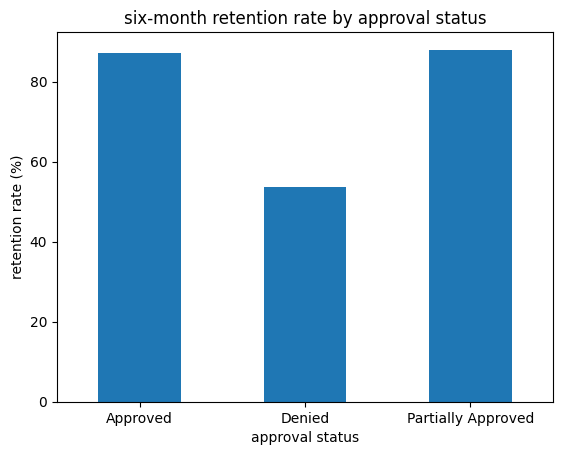

In [38]:
import matplotlib.pyplot as plt

retention_rates = (
    df.groupby("approval_status")["retained_6mo"]
    .mean()
    .mul(100)
)

retention_rates.plot(kind="bar")

plt.title("six-month retention rate by approval status")
plt.xlabel("approval status")
plt.ylabel("retention rate (%)")
plt.xticks(rotation=0)
plt.show()

### retention by approval status interpretation

there is a large difference in six-month retention across approval outcomes. employees with approved requests had a retention rate of 87.2%, while partially approved requests had a similar retention rate of 88.0%.

in comparison, employees whose accommodation requests were denied had a retention rate of only 53.6%. this is approximately 34 percentage points lower than the retention rate for approved requests.

this suggests that denied accommodation requests are strongly associated with lower employee retention in this dataset. however, this analysis shows an association and does not prove that denial itself causes employees to leave.

### 9.2 implementation delay and retention

the client also suggested examining whether longer implementation times are connected to employee retention. to explore this, i compare the average and median number of implementation days between employees who were retained after six months and those who were not.

this is an exploratory comparison rather than a causal test. the goal is to see whether the dataset provides evidence of a relationship between accommodation delays and retention.

In [39]:
# compare implementation time by six-month retention outcome

delay_retention = (
    df.dropna(subset=["days_to_implement", "retained_6mo"])
      .groupby("retained_6mo")["days_to_implement"]
      .agg(["count", "mean", "median", "std"])
      .round(2)
)

delay_retention

,count,mean,median,std
retained_6mo,,,,
0,24,21.58,17.5,18.61
1,167,17.92,15.0,12.57


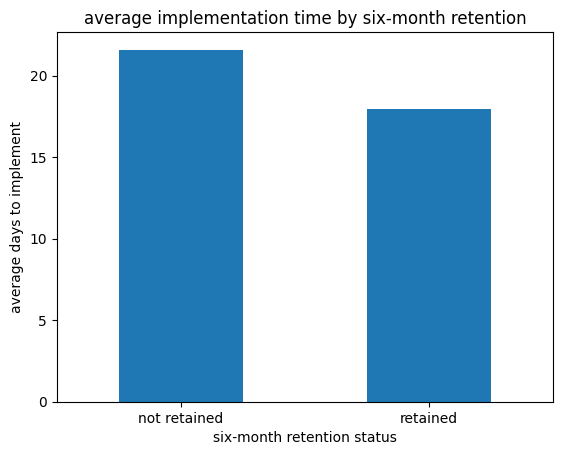

In [40]:
import matplotlib.pyplot as plt

delay_by_retention = (
    df.dropna(subset=["days_to_implement", "retained_6mo"])
      .groupby("retained_6mo")["days_to_implement"]
      .mean()
)

delay_by_retention.index = delay_by_retention.index.map({
    0: "not retained",
    1: "retained"
})

delay_by_retention.plot(kind="bar")

plt.title("average implementation time by six-month retention")
plt.xlabel("six-month retention status")
plt.ylabel("average days to implement")
plt.xticks(rotation=0)
plt.show()

### implementation delay interpretation

employees who were not retained after six months had a higher average implementation time of 21.58 days, compared with 17.92 days for employees who were retained. the median also followed the same pattern, at 17.5 days for employees who were not retained compared with 15 days for retained employees.

this suggests that longer accommodation delays may be associated with lower employee retention. however, the difference is relatively small and the not-retained group contains only 24 observations, so this should not be interpreted as evidence that implementation delays directly cause employees to leave.

combined with the earlier approval status analysis, the results suggest that accommodation outcomes may be connected to retention, especially since denied requests had a much lower six-month retention rate. these findings support considering both approval decisions and implementation delays when evaluating the accommodation process.

## 10. final recommendation

the final step is to combine the exploratory analysis and modelling results to determine which proposed intervention is best supported by the dataset.

the three options considered were:

- **option a:** expand general hr training and review across departments and accommodation categories.
- **option b:** focus resources mainly on reducing financial barriers associated with accommodations.
- **option c:** use a targeted approach based on the specific disability categories, reviewers, departments, and other factors associated with different accommodation outcomes.

the following section compares the evidence collected throughout the analysis before selecting a final recommendation.

In [41]:
evidence_summary = pd.DataFrame({
    "finding": [
        "approval prediction",
        "disability category",
        "hr reviewer",
        "accommodation cost",
        "implementation time",
        "employee retention"
    ],
    "evidence": [
        "logistic regression performed slightly better than the baseline",
        "disability categories appeared among important model coefficients",
        "individual hr reviewers appeared among important model coefficients",
        "cost was not consistently the strongest predictor of approval",
        "implementation time was difficult to predict from available features",
        "denied requests had substantially lower six-month retention"
    ],
    "supports_targeted_approach": [
        "yes",
        "yes",
        "yes",
        "yes",
        "partially",
        "yes"
    ]
})

evidence_summary

,finding,evidence,supports_targeted_approach
0,approval prediction,logistic regression performed slightly better ...,yes
1,disability category,disability categories appeared among important...,yes
2,hr reviewer,individual hr reviewers appeared among importa...,yes
3,accommodation cost,cost was not consistently the strongest predic...,yes
4,implementation time,implementation time was difficult to predict f...,partially
5,employee retention,denied requests had substantially lower six-mo...,yes


### interpretation of the combined evidence

the results provide the strongest support for **option c, a targeted intervention approach**.

option a proposed expanding general hr training across the organization. however, the analysis suggests that accommodation outcomes are not uniform across all requests. disability category and individual hr reviewers appeared among the more influential features in the logistic regression model. for example, cognitive/neurological disability was negatively associated with approval and positively associated with denial, while physical/mobility disability showed the opposite pattern. differences also appeared between individual hr reviewers. this suggests that specific areas may require more attention rather than applying the same intervention everywhere.

option b focused mainly on financial barriers. the analysis does not provide strong enough evidence that accommodation cost is the primary issue. cost-related variables appeared in some results, but they were not consistently the strongest predictors of approval status. therefore, focusing primarily on funding would not address all of the patterns found in the data.

option c is better supported because it allows interventions to be directed toward the disability categories, reviewers, departments, and accommodation types where differences appear. the retention analysis also strengthens the importance of improving accommodation outcomes. employees with denied requests had a six-month retention rate of 53.6%, compared with 87.2% for approved requests and 88.0% for partially approved requests.

overall, i recommend **option c**. rather than expanding the same intervention across the entire organization or focusing mainly on cost, the organization should use the identified patterns to investigate and target areas where accommodation outcomes appear less favourable.

## 11. limitations

there are several limitations that should be considered when interpreting these results.

first, the dataset contains only 260 accommodation requests, which limits the amount of data available for training and testing the models. some approval categories also contain fewer observations than others.

second, the classification models showed relatively weak predictive performance. logistic regression achieved an accuracy of 55.8%, only slightly higher than the 53.8% dummy baseline. therefore, the model coefficients are used as exploratory evidence of patterns in the dataset rather than proof of discrimination or causation.

the implementation-time models were also weak. linear regression performed best, but its r² value was only 0.027, meaning that the available variables explained very little of the variation in implementation time.

finally, the relationships found in this analysis are associations. for example, the lower retention rate among employees with denied requests does not prove that denial caused them to leave. other factors that are not included in the dataset may also affect retention and accommodation outcomes.

because of these limitations, the results should be used to identify areas for further investigation rather than to make conclusions about individual employees or hr reviewers.